In [43]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from collections import Counter
from dataclasses import field
from pydantic import BaseModel, Field,  field_validator
from typing import List, Tuple, Literal
from openai import OpenAI
from any_llm import completion
from tqdm import tqdm
from collections import Counter


import SoD_Utils
import Text_Utils

In [2]:
LANGUAGE = SoD_Utils.LANGUAGE_CZ

provider=(
    # "ollama"
    "openai"
)
model=(
    # "jean-luc/tiger-gemma-9b-v3:fp16"
    "gpt-4.1-nano"
)

data_path = path = SoD_Utils.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3880 entries, 0 to 3879
Columns: 170 entries, id to lca_DK_n_8
dtypes: category(163), float64(7)
memory usage: 864.0 KB


In [3]:
def process_SoD_response(row):
    # --- 1. Basic Information ---
    # Renames Czech keys to English and performs initial data cleaning.
    processed_data = {
        'gender': row.get('GENDER').lower(),
        'age': int(row.get('AGE1', 0)),
        'education_level': row.get('EDU', '').lower(),
        'region': row.get('KRAJ'),
        'district': row.get('OKRES'),
        'town_size': SoD_Utils.process_town_size(row),
        'employment_status': SoD_Utils.process_employment(row),
        'income_range': SoD_Utils.process_income(row),
        'voted_party': row.get('Q21')
    }

    # --- 2. Additional Survey Questions ---
    # Merges the dictionary of additional questions into the main one.
    additional_data = {
        'living_standard': row.get('Q19','').lower(),
        'interest_in_politics': row.get('Q20','').lower(),
        'opinion_on_eu': row.get('Q18','').lower(),
        'opinion_on_nato': row.get('Q17','').lower(),
        'covid_vaccinated': row.get('Q23','').lower(),
    }
    processed_data.update(additional_data)


    return processed_data

data = [process_SoD_response(df.loc[i]) for i in df.index]
data = pd.DataFrame(data, index=df.index)

In [4]:
data

,gender,age,education_level,region,district,town_size,employment_status,income_range,voted_party,living_standard,interest_in_politics,opinion_on_eu,opinion_on_nato,covid_vaccinated
0,muž,28,vysokoškolské vzdělání,Středočeský kraj,Nymburk,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,Koalice PIRÁTI a STAROSTOVÉ,spíše dobrou,velmi se zajímám,spíše spokojený/á,rozhodně spokojený/á,ano
1,muž,27,vysokoškolské vzdělání,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,Koalice PIRÁTI a STAROSTOVÉ,spíše dobrou,spíše se zajímám,spíše spokojený/á,spíše spokojený/á,ano
2,žena,33,základní + středoškolské vzdělání bez maturity,Královéhradecký kraj,Jičín,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,25.001 - 30.000 Kč,ANO 2011,"ani dobrou, ani špatnou",spíše se zajímám,spíše spokojený/á,rozhodně spokojený/á,ano
3,žena,27,základní + středoškolské vzdělání bez maturity,Plzeňský kraj,Rokycany,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,Nechci uvést,spíše dobrou,spíše se zajímám,rozhodně spokojený/á,rozhodně spokojený/á,ano
4,muž,21,středoškolské vzdělání s maturitou,Ústecký kraj,Chomutov,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,Jiná strana,velmi dobrou,vůbec se nezajímám,rozhodně spokojený/á,rozhodně spokojený/á,ano
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3875,žena,39,středoškolské vzdělání s maturitou,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,ANO 2011,spíše dobrou,spíše se nezajímám,spíše spokojený/á,spíše spokojený/á,ne
3876,žena,30,vysokoškolské vzdělání,Hlavní město Praha,Praha,Více než 100.000 obyvatel,zaměstnanec na částečný úvazek,None,Koalice PIRÁTI a STAROSTOVÉ,spíše dobrou,spíše se zajímám,rozhodně spokojený/á,rozhodně spokojený/á,ano
3877,žena,47,vysokoškolské vzdělání,Moravskoslezský kraj,Karviná,5.001 - 20.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,Nechci uvést,spíše dobrou,vůbec se nezajímám,spíše spokojený/á,rozhodně spokojený/á,ano
3878,žena,23,středoškolské vzdělání s maturitou,Hlavní město Praha,Praha,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,Nechci uvést,spíše špatnou,nevím,nevím,nevím,nechci uvést


In [5]:
def _format_opinion_statement(gender, opinion, topic_string):
    """
    Creates a full opinion sentence with correct gendered adjectives.
    Example: (gender='Muž', opinion='Rozhodně ano', topic='EU')
             -> "Jsem rozhodně přesvědčený, že je Česká republika členem EU."

    This helper removes code duplication for the EU and NATO questions.
    """
    if opinion == 'Nevím':
        return "" # Return an empty string if there is no opinion

    return f"Jsem {Text_Utils.declension_gender_ya(opinion[:-3],gender).lower()}, že je Česká republika členským státem {topic_string}."
# --- Main Function to Create the Description ---

def create_respondent_description(respondent):
    """
    Generates a descriptive Czech paragraph about a survey respondent
    by combining their answers into grammatically correct sentences.

    Args:
        respondent (dict): A dictionary containing the processed data for one person,
                           with English keys (e.g., 'gender', 'region').

    Returns:
        str: A multi-sentence description of the respondent in Czech.
    """
    # --- 1. Build the description sentence by sentence ---
    # Using a list of sentences is cleaner than repeated string concatenation.
    gender = SoD_Utils.gender_to_enum_gender(respondent['gender'])
    description_parts = []

    # --- Basic Demographics ---
    description_parts.append(
        f"Jsem {respondent['gender']}, "
        f"je mi {respondent['age']} let, "
        f"mé vzdělání je {respondent['education_level']}."
    )

    # --- Location ---
    # This now uses the helper function for complex Czech grammar.
    description_parts.append(
        f"Žiji v {SoD_Utils.decline_region_to_Locative(respondent['region'])}, "
        f"v okresu {respondent['district']} a "
        f"obci o velikosti {respondent['town_size']}."
    )

    # --- Socioeconomic Status ---
    description_parts.append(f"Z hlediska zaměstnání jsem {respondent['employment_status']}")
    if respondent['income_range']:
        description_parts.append(f"a příjem naší domácnosti je {respondent['income_range']}")
    description_parts[-1]+="."

    # EU and NATO opinions now use the dedicated helper function
    description_parts.append(_format_opinion_statement(gender, respondent['opinion_on_eu'], "EU"))
    description_parts.append(_format_opinion_statement(gender, respondent['opinion_on_nato'], "NATO"))

    # Living Standard
    living_standard = respondent['living_standard']
    if SoD_Utils.is_non_substantive_responses(living_standard):
        verb = 'mám'
        if 'ani' in respondent['living_standard']:
            verb = Text_Utils.declension_negation_ne(verb)
        description_parts.append(f"{verb.capitalize()} {living_standard} životní úroveň.")

    # Interest in Politics
    interest = respondent['interest_in_politics']
    if SoD_Utils.is_non_substantive_responses(interest):
        description_parts.append(f"{interest.capitalize()} o politiku.")

    # COVID Vaccination Status
    vacc_status = respondent['covid_vaccinated']
    if SoD_Utils.is_non_substantive_responses(vacc_status):
        is_vaccinated = Text_Utils.parse_yes_no(vacc_status)
        verb = 'jsem'
        if not is_vaccinated:
            verb = Text_Utils.declension_negation_ne(verb)
        description_parts.append(f"{verb.capitalize()} {Text_Utils.declension_gender_ya('očkován',gender)} proti covidu.")

    # --- 2. Combine all parts into a final paragraph ---
    # Filter out any empty strings that may have been returned by helpers (e.g., for 'Nevím' answers)
    # and join the parts with a space.
    full_description = " ".join(part for part in description_parts if part)

    return full_description

In [6]:
create_respondent_description(data.iloc[1687])

'Jsem žena, je mi 42 let, mé vzdělání je středoškolské vzdělání s maturitou. Žiji v Ústeckém kraji, v okresu Chomutov a obci o velikosti 5.001 - 20.000 obyvatel. Z hlediska zaměstnání jsem zaměstnanec na plný úvazek. Jsem neá, že je Česká republika členským státem EU. Jsem neá, že je Česká republika členským státem NATO.'

## Calling prompts

In [7]:
INSTRUCTIONS ="""
Jsi expertní AI asistent specializovaný na analýzu českého politického chování. Tvým úkolem je na základě demografického a postojového profilu respondenta odhadnout jeho volební chování ve volbách do Poslanecké sněmovny Parlamentu ČR v roce 2021.

Tvůj výstup MUSÍ být JSON objekt, který přesně odpovídá Pydantic modelu `VotingResult`. Jiný formát není přípustný.

Dodržuj tato pravidla:
1.  Analyzuj VŠECHNY poskytnuté informace o respondentovi (věk, vzdělání, bydliště, příjem, postoje k EU/NATO atd.).
2.  Na základě analýzy odhadni dvě klíčové věci:
    a) Jaká je pravděpodobnost, že respondent vůbec šel k volbám.
    b) Pokud volil, jaké jsou pravděpodobnosti pro jednotlivé politické strany.
3.  Vygeneruj JSON, který bude validní oproti poskytnutým Pydantic modelům.
4.  Dbej na to, aby součet pravděpodobností v objektu `voted_or_not` byl přesně 1.0.
5.  Dbej na to, aby součet pravděpodobností VŠECH stran v seznamu `parties` byl přesně 1.0."""


czech_prompt_end = " Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:"

In [8]:
class PartyProbability(BaseModel):
    """
    Strukturovaná reprezentace pravděpodobnosti hlasování pro konkrétní stranu.
    """
    name: Literal[
        "ANO 2011",
        "Koalice Spolu (ODS, TOP 09, KDU-ČSL)",
        "Koalice PIRÁTI a STAROSTOVÉ",
        "Komunistická strana Čech a Moravy (KSČM)",
        "Svoboda a přímá demokracie – Tomio Okamura (SPD)",
        "Česká strana sociálně demokratická (ČSSD)",
        "Trikolóra, Svobodní a Soukromníci",
        "Přísaha Roberta Šlachty",
        "Jiná strana"
    ] = Field(description="Název politické strany.")
    probability: float = Field(
        ge=0, le=1, description="Pravděpodobnost, že respondent hlasoval pro tuto stranu."
    )

class VotedProbability(BaseModel):
    """
    Pravděpodobnost, zda respondent volil, nebo nevolil.
    """
    voted: float = Field(ge=0, le=1, description="Pravděpodobnost, že respondent volil.")
    not_voted: float = Field(ge=0, le=1, description="Pravděpodobnost, že respondent nevolil.")

    # @field_validator('*', pre=True, always=True)
    # def check_sum(cls, v, values):
    #     # Tento validátor zajistí, že součet se bude blížit 1.0
    #     # Můžete si pohrát s tolerancí (např. 0.01)
    #     if 'voted' in values and 'not_voted' in values:
    #         if abs(values['voted'] + values['not_voted'] - 1.0) > 0.001:
    #             raise ValueError("Součet pravděpodobností pro 'voted' a 'not_voted' se musí rovnat 1.0")
    #     return v

class VotingResult(BaseModel):
    """
    Strukturovaný výstup pro volební chování respondenta ve volbách do poslanecké sněmovny 2021.
    """
    # Změna zde: použití nové třídy místo složitého Tuple
    voted_or_not: VotedProbability = Field(
        description="Pravděpodobnost, zda respondent volil, nebo nevolil. Součet musí být 1.0."
    )
    parties: List[PartyProbability] = Field(
        description="Seznam možných stran s pravděpodobností volby. Součet pravděpodobností musí být 1.0."
    )

In [76]:
respondent = data.iloc[0]
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
prompt = create_respondent_description(respondent) + czech_prompt_end

In [77]:
response = client.responses.parse(
    model="gpt-4.1-nano",
    temperature=0,
    #instructions=INSTRUCTIONS,
    input=input,
    text_format=VotingResult
)

voted = response.output_parsed
response.output_parsed

VotingResult(voted_or_not=VotedProbability(voted=0.7, not_voted=0.3), parties=[PartyProbability(name='ANO 2011', probability=0.2), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.3), PartyProbability(name='Koalice PIRÁTI a STAROSTOVÉ', probability=0.15), PartyProbability(name='Komunistická strana Čech a Moravy (KSČM)', probability=0.05), PartyProbability(name='Svoboda a přímá demokracie – Tomio Okamura (SPD)', probability=0.1), PartyProbability(name='Česká strana sociálně demokratická (ČSSD)', probability=0.1), PartyProbability(name='Trikolóra, Svobodní a Soukromníci', probability=0.05), PartyProbability(name='Přísaha Roberta Šlachty', probability=0.03), PartyProbability(name='Jiná strana', probability=0.02)])

In [78]:
response = completion(
    provider=provider,
    model=model,
    temperature=0,
    messages=[
        # {"role": "system", "content": INSTRUCTIONS},
        {"role": "user", "content": prompt }
    ],
    response_format=VotingResult
)
voted = VotingResult.model_validate_json(response.choices[0].message.content)
response.choices[0].message

ChatCompletionMessage(content='{"voted_or_not":{"voted":1.0,"not_voted":0.0},"parties":[{"name":"ANO 2011","probability":0.0},{"name":"Koalice Spolu (ODS, TOP 09, KDU-ČSL)","probability":0.0},{"name":"Koalice PIRÁTI a STAROSTOVÉ","probability":0.0},{"name":"Komunistická strana Čech a Moravy (KSČM)","probability":0.0},{"name":"Svoboda a přímá demokracie – Tomio Okamura (SPD)","probability":0.0},{"name":"Česká strana sociálně demokratická (ČSSD)","probability":0.0},{"name":"Trikolóra, Svobodní a Soukromníci","probability":0.0},{"name":"Přísaha Roberta Šlachty","probability":0.0},{"name":"Jiná strana","probability":0.0}]}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None, reasoning=None, parsed={'voted_or_not': {'voted': 1.0, 'not_voted': 0.0}, 'parties': [{'name': 'ANO 2011', 'probability': 0.0}, {'name': 'Koalice Spolu (ODS, TOP 09, KDU-ČSL)', 'probability': 0.0}, {'name': 'Koalice PIRÁTI a STAROSTOVÉ', 'probability': 0.0}, {'name': 'Komun

In [79]:
p = 0
print(voted.voted_or_not)
for party_vote in voted.parties:
    print(f"{party_vote.name}: {party_vote.probability}")
    p += party_vote.probability
print(f"p_sum = {p}")

respondent["voted_party"]

voted=1.0 not_voted=0.0
ANO 2011: 0.0
Koalice Spolu (ODS, TOP 09, KDU-ČSL): 0.0
Koalice PIRÁTI a STAROSTOVÉ: 0.0
Komunistická strana Čech a Moravy (KSČM): 0.0
Svoboda a přímá demokracie – Tomio Okamura (SPD): 0.0
Česká strana sociálně demokratická (ČSSD): 0.0
Trikolóra, Svobodní a Soukromníci: 0.0
Přísaha Roberta Šlachty: 0.0
Jiná strana: 0.0
p_sum = 0.0


'Koalice PIRÁTI a STAROSTOVÉ'

### RUN experiment


In [29]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
respondents = data.sample(n=200, random_state=42)
voting_results = {}

In [30]:
pbar = tqdm(respondents.index)
for i in pbar:
    respondent = respondents.loc[i]

    # response = completion(
    #     provider=provider,
    #     model=model,
    #     temperature=0,
    #     messages=[
    #         #{"role": "system", "content": INSTRUCTIONS},
    #         {"role": "user", "content": prompt }
    #     ],
    #     response_format=VotingResult
    # )
    # voted = VotingResult.model_validate_json(response.choices[0].message.content)

    response = client.responses.parse(
        model="gpt-4.1-nano",
        temperature=0,
        #instructions=INSTRUCTIONS,
        input=create_respondent_description(respondent) + czech_prompt_end,
        text_format=VotingResult
    )
    voted = response.output_parsed
    voting_results[i] = voted
    pbar.set_postfix({'text': voted})


100%|██████████| 200/200 [07:36<00:00,  2.28s/it, text=voted_or_not=VotedProbability(voted=0.5, not_voted=0.5) parties=[PartyProbability(name='ANO 2011', probability=0.1), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.2), PartyProbability(name='Koalice PIRÁTI a STAROSTOVÉ', probability=0.15), PartyProbability(name='Komunistická strana Čech a Moravy (KSČM)', probability=0.05), PartyProbability(name='Svoboda a přímá demokracie – Tomio Okamura (SPD)', probability=0.1), PartyProbability(name='Česká strana sociálně demokratická (ČSSD)', probability=0.1), PartyProbability(name='Trikolóra, Svobodní a Soukromníci', probability=0.05), PartyProbability(name='Přísaha Roberta Šlachty', probability=0.05), PartyProbability(name='Jiná strana', probability=0.2)]]   


In [31]:
print(len(respondents), len(voting_results))

200 200


### Save Results

In [32]:
def save_results_to_json(results: List[VotingResult], filename: str):
    """
    Serializes a list of VotingResult objects and saves them to a JSON file.

    Args:
        results: A list of VotingResult Pydantic objects.
        filename: The path to the file where the results will be saved.
    """
    # Convert each Pydantic model to a dictionary using .model_dump()
    results_as_dicts = [result.model_dump() for result in results]

    try:
        with open(filename, 'w', encoding='utf-8') as f:
            # Use json.dump to write the list of dicts to the file
            # ensure_ascii=False correctly handles Czech characters
            # indent=4 makes the file human-readable
            json.dump(results_as_dicts, f, ensure_ascii=False, indent=4)
        print(f"Successfully saved {len(results)} results to {filename}")
    except IOError as e:
        print(f"Error writing to file {filename}: {e}")

def load_results_from_json(filename: str) -> List[VotingResult]:
    """
    Loads voting results from a JSON file and deserializes them into
    a list of VotingResult objects.

    Args:
        filename: The path to the JSON file to load.

    Returns:
        A list of VotingResult objects.
    """
    loaded_results = []
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            # Load the raw data from the JSON file
            data_from_file = json.load(f)

            # Re-create Pydantic models from the loaded dictionaries
            # This automatically validates the data against your schema
            for item in data_from_file:
                loaded_results.append(VotingResult(**item))

        print(f"Successfully loaded and validated {len(loaded_results)} results from {filename}")
        return loaded_results
    except FileNotFoundError:
        print(f"Error: The file {filename} was not found.")
        return []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from the file {filename}.")
        return []


In [33]:
save_results_to_json(voting_results.values(), "voting_results.json")

Successfully saved 200 results to voting_results.json


In [102]:
# voting_results_loaded = load_results_from_json("voting_results.json")
# voting_results_loaded

Successfully loaded and validated 14 results from voting_results.json


[VotingResult(voted_or_not=VotedProbability(voted=0.7, not_voted=0.3), parties=[PartyProbability(name='ANO 2011', probability=0.2), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.3), PartyProbability(name='Koalice PIRÁTI a STAROSTOVÉ', probability=0.15), PartyProbability(name='Komunistická strana Čech a Moravy (KSČM)', probability=0.05), PartyProbability(name='Svoboda a přímá demokracie – Tomio Okamura (SPD)', probability=0.1), PartyProbability(name='Česká strana sociálně demokratická (ČSSD)', probability=0.1), PartyProbability(name='Trikolóra, Svobodní a Soukromníci', probability=0.05), PartyProbability(name='Přísaha Roberta Šlachty', probability=0.03), PartyProbability(name='Jiná strana', probability=0.02)]),
 VotingResult(voted_or_not=VotedProbability(voted=0.7, not_voted=0.3), parties=[PartyProbability(name='ANO 2011', probability=0.2), PartyProbability(name='Koalice Spolu (ODS, TOP 09, KDU-ČSL)', probability=0.3), PartyProbability(name='Koalice PIRÁTI 

### Visualization

In [41]:
# --- Data Aggregation and Visualization ---


def aggregate_results(results: List[VotingResult]) -> tuple[pd.DataFrame, pd.Series]:
    """
    Aggregates probabilities for parties and election attendance.
    """
    # Aggregate party probabilities
    party_probs = {}
    for result in results:
        for party in result.parties:
            if party.name not in party_probs:
                party_probs[party.name] = []
            party_probs[party.name].append(party.probability)

    party_df = pd.DataFrame.from_dict(
        {k: sum(v) / len(v) for k, v in party_probs.items()},
        orient='index',
        columns=['Predicted Probability']
    ).sort_values('Predicted Probability', ascending=False)
    party_df['Predicted Probability']/= party_df['Predicted Probability'].sum()

    # Aggregate voted/not_voted probabilities
    voted_sum = sum(r.voted_or_not.voted for r in results)
    not_voted_sum = sum(r.voted_or_not.not_voted for r in results)
    total_respondents = len(results)

    attendance_s = pd.Series({
        "Voted": voted_sum / total_respondents,
        "Not Voted": not_voted_sum / total_respondents
    })

    return party_df, attendance_s

def visualize_comprehensive_results(
    predicted_df: pd.DataFrame,
    attendance_s: pd.Series,
    actual_results: dict
):
    """
    Generates a two-part plot using pure Matplotlib:
    1. A bar chart for predicted election attendance.
    2. A grouped bar chart comparing predicted party probabilities with actual results.
    """
    # Create a figure with two subplots, stacked vertically
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 14),
        sharex=False,
        gridspec_kw={'height_ratios': [1, 5]} # ax2 is 5x taller than ax1
    )
    fig.suptitle('Analysis of Predicted Voting Behavior vs. 2021 Actual Results', fontsize=20, y=0.96)

    # --- Plot 1: Election Attendance Probability ---
    ax1.barh(attendance_s.index, attendance_s.values, color=['#4CAF50', '#F44336'], height=0.6)
    ax1.set_title('Predicted Election Attendance', fontsize=14)
    ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax1.set_xlim(0, 1)
    # Add value labels
    for index, value in enumerate(attendance_s.values):
        ax1.text(value + 0.02, index, f'{value:.1%}', va='center', fontsize=12)

    # --- Plot 2: Predicted vs. Actual Party Results ---
    # Prepare data for grouped bar chart
    labels = predicted_df.index
    predicted_probs = predicted_df['Predicted Probability']

    # Map actual results to the same order as predicted, converting to 0-1 scale
    actual_probs_percent = [actual_results.get(label, 0) for label in labels]
    actual_probs = [p / 100.0 for p in actual_probs_percent]

    y = np.arange(len(labels))  # the label locations
    height = 0.4  # the height of the bars

    # Plot the bars
    rects1 = ax2.barh(y + height / 2, predicted_probs, height, label='Predicted', color='skyblue')
    rects2 = ax2.barh(y - height / 2, actual_probs, height, label='Actual 2021 Result', color='steelblue')

    # Add some text for labels, title and axes ticks
    ax2.set_title('Comparison of Predicted vs. Actual Election Results', fontsize=16)
    ax2.set_xlabel('Probability / Vote Share', fontsize=12)
    ax2.set_yticks(y, labels)
    ax2.invert_yaxis()  # labels read top-to-bottom
    ax2.legend(fontsize=12)
    ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Add value labels for both sets of bars
    ax2.bar_label(rects1, padding=3, fmt='{:.1%}', fontsize=10)
    ax2.bar_label(rects2, padding=3, fmt='{:.1%}', fontsize=10)

    ax2.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

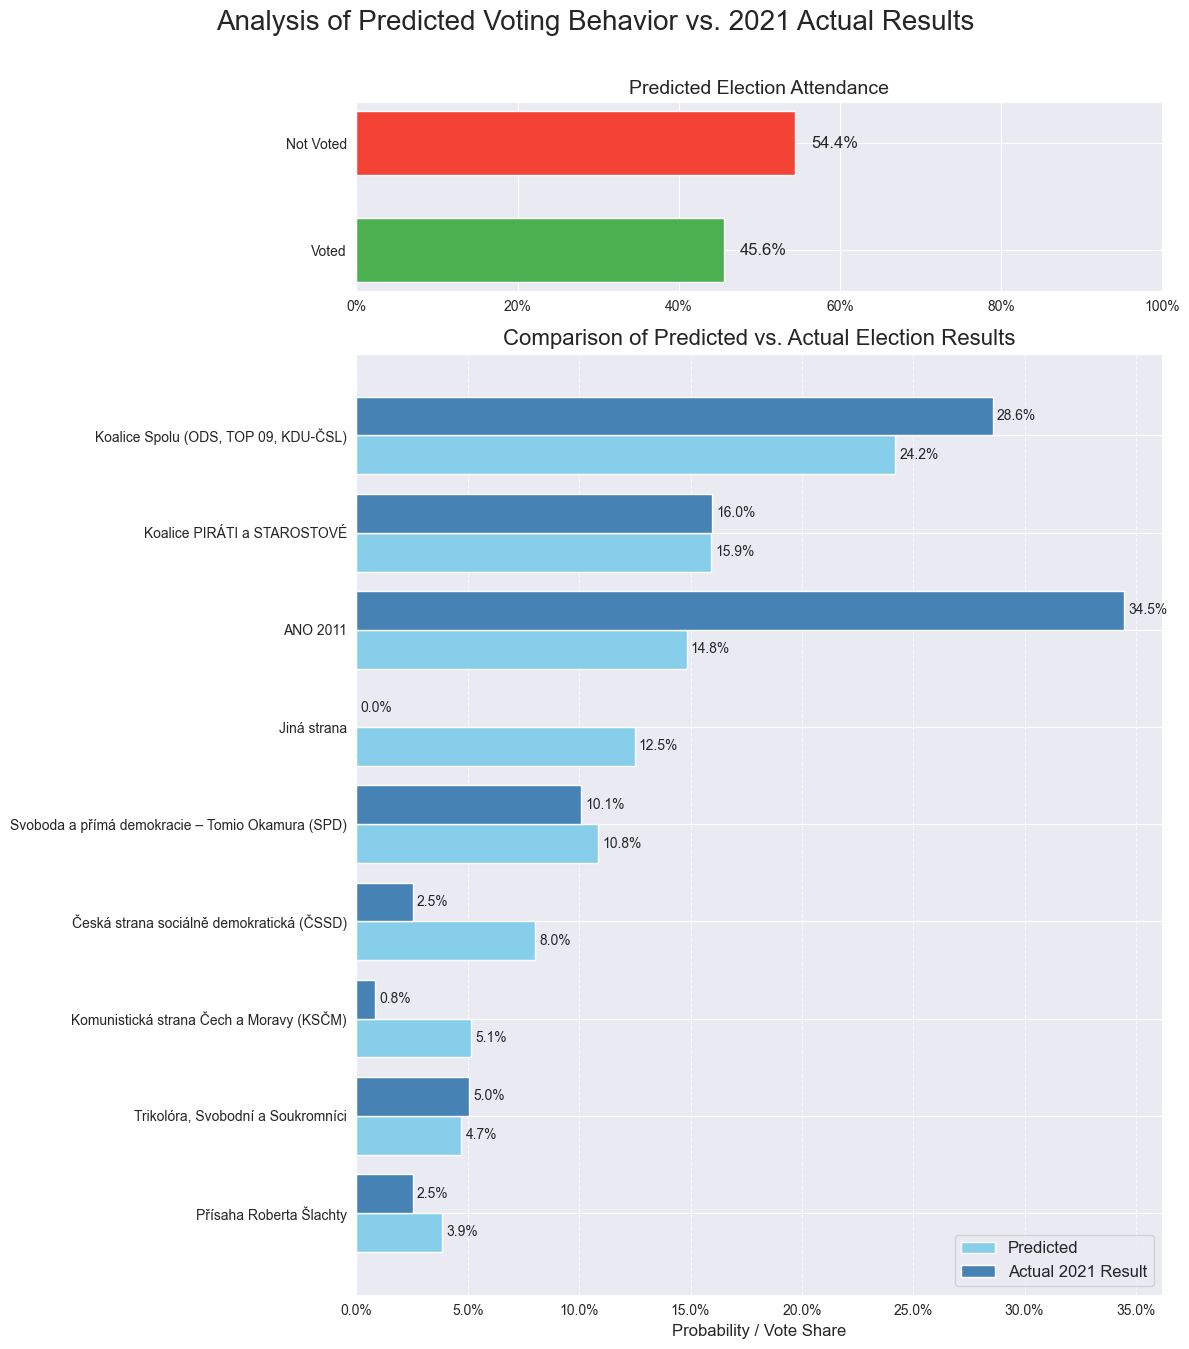

In [47]:
predicted_parties_df, attendance_series = aggregate_results(voting_results.values())
from collections import Counter

# Your list of strings
votes = [vote for vote in respondents["voted_party"].to_list() if not SoD_Utils.is_non_substantive_responses(vote) and not "Nebyl" in vote]
actual_results = {key: 100 * value / len(votes) for key, value in Counter(votes).items()}

# Visualize the results
visualize_comprehensive_results(
    predicted_parties_df,
    attendance_series,
    actual_results
    # {
    #     "ANO 2011":27.12,
    #     "Koalice Spolu (ODS, TOP 09, KDU-ČSL)":27.79,
    #     "Koalice PIRÁTI a STAROSTOVÉ":15.62,
    #     "Komunistická strana Čech a Moravy (KSČM)":3.60,
    #     "Svoboda a přímá demokracie – Tomio Okamura (SPD)":9.56,
    #     "Česká strana sociálně demokratická (ČSSD)":4.65,
    #     "Trikolóra, Svobodní a Soukromníci":2.76,
    #     "Přísaha Roberta Šlachty":4.68,
    #     "Jiná strana":4.22
    # }
)

In [36]:
def plot_party_frequencies(party_list: List[str]):
    """
    Calculates the frequency of each party in a list and plots the result
    as a horizontal bar chart using Matplotlib.

    Args:
        party_list: A list of strings, where each string is a party name.
    """
    if not party_list:
        print("The provided list is empty. Cannot generate a plot.")
        return

    # Count frequencies and calculate probabilities
    counts = Counter(party_list)
    total_votes = len(party_list)

    # Create a pandas DataFrame for easy sorting and handling
    df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
    df['Probability'] = df['Count'] / total_votes
    df = df.sort_values('Probability', ascending=True)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 7))

    # Create horizontal bars
    bars = ax.barh(df.index, df['Probability'], color='teal')

    # Set title and labels
    ax.set_title('Frequency of Votes per Party', fontsize=16)
    ax.set_xlabel('Share of Votes', fontsize=12)
    ax.set_ylabel('Party', fontsize=12)

    # Format the x-axis as a percentage
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(0, max(df['Probability']) * 1.15) # Add some space for labels

    # Add value labels to the end of each bar
    ax.bar_label(bars, padding=5, fmt='{:.1%}', fontsize=11)

    # Add a grid for better readability
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


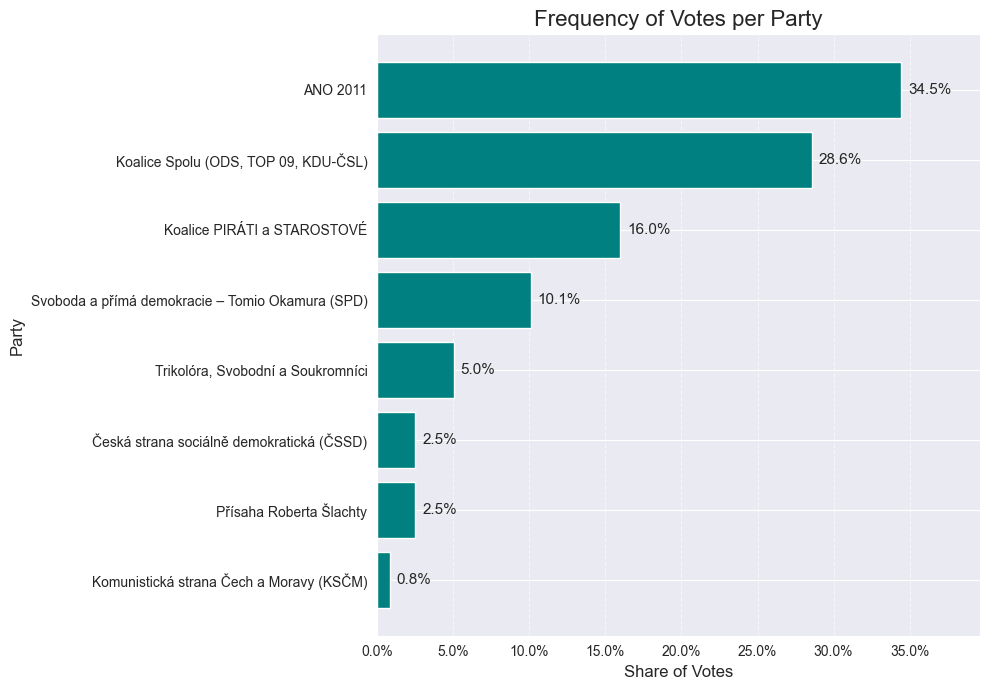

In [38]:
plot_party_frequencies([vote for vote in respondents["voted_party"].to_list() if not SoD_Utils.is_non_substantive_responses(vote) and not "Nebyl" in vote])